In [26]:
from collections import defaultdict
import datetime
from itertools import combinations 
import os
import pickle
import time


#importing required packages 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns
from scipy.stats import pearsonr, chi2_contingency

#ML
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn import preprocessing
from sklearn import naive_bayes
from sklearn import discriminant_analysis
from sklearn.metrics import confusion_matrix

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
pd.set_option('display.max_columns', None)

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_79305/3005236126.py:31: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


In [27]:
#reading in our data locally through our main csv file 
raw_data = pd.read_csv('data/accepted_2007_to_2018Q4.csv')
raw_data.head()

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_79305/3855803610.py:2: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv('data/accepted_2007_to_2018Q4.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

In [28]:
#creating our dependent variable
raw_data.groupby('loan_status')['id'].count()

loan_status
Charged Off                                             268559
Current                                                 878317
Default                                                     40
Does not meet the credit policy. Status:Charged Off        761
Does not meet the credit policy. Status:Fully Paid        1988
Fully Paid                                             1076751
In Grace Period                                           8436
Late (16-30 days)                                         4349
Late (31-120 days)                                       21467
Name: id, dtype: int64

In [568]:
data = raw_data.loc[raw_data['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])]
data.shape

(1345350, 151)

In [569]:
# reclassify all charged off loans as default
data.loc[data['loan_status'] == 'Charged Off', 'loan_status'] = 'Default'

In [570]:
# reclassify all default loans as 0 and fully paid loans as 1
data.loc[data['loan_status'] == 'Default', 'loan_status'] = 0
data.loc[data['loan_status'] == 'Fully Paid', 'loan_status'] = 1

In [571]:
#timing decorator
def tdec(func):
    def inner(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        print('{} sec to complete {}'.format(np.round(time.time() - start_time, 1), func))
        return result
    return inner 

#creating function to quickly get an idea of values that comprise feature 
def variable_expl(variable):
    print(accepted_df[variable].value_counts())
    print(' ')
    print('Number of NA\'s is:', accepted_df[variable].isna().sum())
    print('Number of unique values is:', accepted_df[variable].nunique())
    if accepted_df[variable].dtype == 'float64' or accepted_df[variable].dtype == 'int64':
        print('Mean is:', np.mean(accepted_df[variable]))
        print('Std.Dev is:', np.std(accepted_df[variable]))

#creating function to return correlation value between two features 
def corr_value(df, variable1, variable2):
    print(df[variable1].corr(df[variable2]))

#creating a function that can print full series values in Jupyter notebook
def print_full(x):
    pd.set_option('display.max_rows', len(x))
    print(x)
    pd.reset_option('display.max_rows')
    
#creating a function to return correlation values between numeric variables
from collections import defaultdict

def correlation(variable):
    dict_output = defaultdict(int)
    for x in accepted_df.columns:
        corr1 = accepted_df[x].corr(accepted_df[variable])
        dict_output[x] = abs(corr1)
    return sorted(dict_output.items(), key = lambda x: x[1], reverse = True)

In [572]:
#fillmean values 
fillmean = ['annual_inc','delinq_amnt','acc_now_delinq','delinq_2yrs','dti','revol_util','inq_last_6mths',
           'open_acc','pub_rec','open_acc_6m','open_act_il','open_il_12m','open_il_24m','mths_since_rcnt_il',
           'il_util','open_rv_12m','open_rv_24m','max_bal_bc','all_util','total_rev_hi_lim','inq_fi',
           'total_cu_tl','inq_last_12m','acc_open_past_24mths','avg_cur_bal','bc_open_to_buy','bc_util',
           'mo_sin_old_il_acct','mo_sin_rcnt_rev_tl_op','mo_sin_rcnt_tl','mths_since_recent_bc',
           'mths_since_recent_inq','num_accts_ever_120_pd','num_actv_bc_tl','num_bc_sats','num_bc_tl','num_il_tl',
           'num_op_rev_tl','num_rev_accts','num_rev_tl_bal_gt_0','num_sats','num_tl_120dpd_2m','num_tl_30dpd',
           'num_tl_90g_dpd_24m','num_tl_op_past_12m','percent_bc_gt_75','tot_hi_cred_lim','total_bc_limit',
           'total_il_high_credit_limit']

#fill zero
fillzero = ['open_acc','pub_rec','inq_last_6mths','tax_liens','collections_12_mths_ex_med','chargeoff_within_12_mths','pub_rec_bankruptcies','emp_length','tot_coll_amt']

def fillvars(accepted_df, fillmean, fillzero):
    var_exceptions = []
    for x in fillmean:
        try: accepted_df[x] = accepted_df[x].fillna(accepted_df[x].mean())
        except:
            var_exceptions.append(x)
            continue
    for d in fillzero:
        try: accepted_df[d] = accepted_df[d].fillna(0)
        except: continue
    return var_exceptions

var_exceptions = fillvars(data, fillmean, fillzero)

var_exceptions

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_79305/807870140.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  try: accepted_df[x] = accepted_df[x].fillna(accepted_df[x].mean())
/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_79305/807870140.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  try: accepted_df[d] = accepted_df[d].fillna(0)


[]

In [573]:
# fill missing zip_code with new category '000xx'
data['zip_code'] = data['zip_code'].fillna('000xx')

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_79305/173246612.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['zip_code'] = data['zip_code'].fillna('000xx')


# Feature Selection 
The dataset has 151 features, but not all features are available to lenders at the point of application. The file "LCDataDictionary.xlsx" contains the features that are visible to lenders when viewing applications, which we use to filter the columns of the dataset. 

In [574]:
feature_notes = pd.read_excel('data/LCDataDictionary.xlsx', sheet_name=1)
feature_defs = feature_notes['BrowseNotesFile'].dropna().values # Drop NaN values
feature_notes.head()

,BrowseNotesFile,Description
0,acceptD,The date which the borrower accepted the offer
1,accNowDelinq,The number of accounts on which the borrower i...
2,accOpenPast24Mths,Number of trades opened in past 24 months.
3,addrState,The state provided by the borrower in the loan...
4,all_util,Balance to credit limit on all trades


In [575]:
import re
feature_defs = [re.sub('(?<![0-9_])(?=[A-Z0-9])', '_', x).lower().strip() for x in feature_defs] # Match format to dataset
data_feat = data.columns.values
np.setdiff1d(feature_defs, data_feat) # returns the elements of feature_defs that are not in data_feat

array(['accept_d', 'credit_pull_d', 'effective_int_rate', 'exp_d',
       'exp_default_rate', 'ils_exp_d', 'is_inc_v', 'list_d', 'msa',
       'mths_since_most_recent_inq', 'mths_since_oldest_il_open',
       'mths_since_recent_loan_delinq', 'review_status',
       'review_status_d', 'service_fee_rate', 'verified_status_joint'],
      dtype='<U35')

In [576]:
np.setdiff1d(data_feat, feature_defs) # returns the elements of data_feat that are not in feature_defs

array(['collection_recovery_fee', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'deferral_term', 'funded_amnt_inv',
       'hardship_amount', 'hardship_dpd', 'hardship_end_date',
       'hardship_flag', 'hardship_last_payment_amount', 'hardship_length',
       'hardship_loan_status', 'hardship_payoff_balance_amount',
       'hardship_reason', 'hardship_start_date', 'hardship_status',
       'hardship_type', 'issue_d', 'last_credit_pull_d',
       'last_fico_range_high', 'last_fico_range_low', 'last_pymnt_amnt',
       'last_pymnt_d', 'loan_status', 'mo_sin_old_il_acct',
       'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
       'next_pymnt_d', 'orig_projected_additional_accrued_interest',
       'out_prncp', 'out_prncp_inv', 'payment_plan_start_date',
       'policy_code', 'pymnt_plan', 'recoveries', 'settlement_amount',
       'settlement_date', 'settlement_percentage', 'settlement_status',
       'settlement_term', 'total_pymnt', 'total_pymnt_inv',
       'total

In [577]:
len(feature_defs)

120

In [578]:
wrong = ['is_inc_v', 'mths_since_most_recent_inq', 'mths_since_oldest_il_open',
         'mths_since_recent_loan_delinq', 'verified_status_joint']
correct = ['verification_status', 'mths_since_recent_inq', 'mo_sin_old_il_acct',
           'mths_since_recent_bc_dlq', 'verification_status_joint']

feature_defs = np.setdiff1d(feature_defs, wrong)
feature_defs = np.append(feature_defs, correct)
feature_defs

array(['acc_now_delinq', 'acc_open_past_24mths', 'accept_d', 'addr_state',
       'all_util', 'annual_inc', 'annual_inc_joint', 'application_type',
       'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'collections_12_mths_ex_med',
       'credit_pull_d', 'delinq_2yrs', 'delinq_amnt', 'desc',
       'disbursement_method', 'dti', 'dti_joint', 'earliest_cr_line',
       'effective_int_rate', 'emp_length', 'emp_title', 'exp_d',
       'exp_default_rate', 'fico_range_high', 'fico_range_low',
       'funded_amnt', 'grade', 'home_ownership', 'id', 'il_util',
       'ils_exp_d', 'initial_list_status', 'inq_fi', 'inq_last_12m',
       'inq_last_6mths', 'installment', 'int_rate', 'list_d', 'loan_amnt',
       'max_bal_bc', 'member_id', 'mo_sin_old_rev_tl_op',
       'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'msa',
       'mths_since_last_delinq', 'mths_since_last_major_derog',
       'mths_since_last_record', 'mths_since_rcnt_il',
       'mths_since_

In [579]:
avail_feat = np.intersect1d(feature_defs, data_feat)
avail_feat =np.append(avail_feat, ['loan_status'])

In [580]:
data = data[avail_feat]

In [581]:
data.shape

(1345350, 110)

In [582]:
#creating month_dict to map str month values to int
month_dict = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}

#creates issue_d_year and issue_d_month variables that will be later used to filter the dataframe 
def date_transformation(df):
    df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line']).astype(np.int64)
    return df

data = date_transformation(data)

/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_79305/930857981.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line']).astype(np.int64)


In [583]:
#dropping irrelevant or missing data features from the start

#dropping certain variables from the get-go in order to reduce processing time during multicollinearity analysis
data = data.drop(['member_id','id','url','desc'], axis = 1)

In [584]:
#looking at variables with highest NA counts
accepted_df_nas = (data.isna().sum()/data.shape[0]).reset_index()
accepted_df_nas.columns = ['Feature','Percent_Missing']
accepted_df_nas = accepted_df_nas.sort_values(by = 'Percent_Missing', ascending=False)
accepted_df_nas.head(15)

,Feature,Percent_Missing
83,sec_app_mths_since_last_major_derog,0.995058
87,sec_app_revol_util,0.986392
74,revol_bal_joint,0.986149
81,sec_app_inq_last_6mths,0.986148
86,sec_app_open_act_il,0.986148
85,sec_app_open_acc,0.986148
84,sec_app_num_rev_accts,0.986148
82,sec_app_mort_acc,0.986148
80,sec_app_fico_range_low,0.986148
79,sec_app_fico_range_high,0.986148


In [585]:
#getting index list of variables wiht > 50% missing values 
index1 = list(accepted_df_nas[accepted_df_nas['Percent_Missing'] > 0.5].index)
#dropping the columns that have missing values > 0.5
data.drop(data.columns[index1], axis = 1, inplace = True)
data.shape

(1345350, 84)

In [586]:
# get number of unique values in each categorical column and show as dataframe
accepted_df_unique = data.nunique().reset_index()
accepted_df_unique.columns = ['Feature','Unique_Values']
accepted_df_unique = accepted_df_unique.sort_values(by = 'Unique_Values', ascending=True)
accepted_df_unique.head(15)

,Feature,Unique_Values
83,loan_status,2
70,term,2
5,application_type,2
24,initial_list_status,2
13,disbursement_method,2
81,verification_status,3
51,num_tl_30dpd,6
22,home_ownership,6
50,num_tl_120dpd_2m,7
21,grade,7


In [587]:
# get list of all numerical columns
num_feat = []
for x in data.columns.values:
    if data[x].dtype == 'int64' or data[x].dtype == 'float64':
        num_feat.append(x)
    else:
        continue
comb_num_feat = list(combinations(num_feat, 2))
print('Num combinations:', len(comb_num_feat))

corrdict = defaultdict(int)
for comb in comb_num_feat:
    corr = data[comb[0]].corr(data[comb[1]])
    corrdict[comb] = np.abs(corr)
corrdict

Num combinations: 2346


defaultdict(int,
            {('acc_now_delinq', 'acc_open_past_24mths'): 0.0035923449427747545,
             ('acc_now_delinq', 'all_util'): 0.013814447223782408,
             ('acc_now_delinq', 'annual_inc'): 0.01337042430725319,
             ('acc_now_delinq', 'avg_cur_bal'): 0.015231268335604967,
             ('acc_now_delinq', 'bc_open_to_buy'): 0.014924812153665227,
             ('acc_now_delinq', 'bc_util'): 0.026271259203984616,
             ('acc_now_delinq',
              'chargeoff_within_12_mths'): 0.04130844721518709,
             ('acc_now_delinq',
              'collections_12_mths_ex_med'): 0.027519538778882836,
             ('acc_now_delinq', 'delinq_2yrs'): 0.12437703588695766,
             ('acc_now_delinq', 'delinq_amnt'): 0.16671607452963208,
             ('acc_now_delinq', 'dti'): 0.0029676750713470124,
             ('acc_now_delinq', 'earliest_cr_line'): 0.0259635964753402,
             ('acc_now_delinq', 'fico_range_high'): 0.03917465368502246,
             ('ac

In [588]:
# sort corrdict in order
corrdict_view = sorted(corrdict.items(), key = lambda x: x[1], reverse = True)
corrdict_view

[(('fico_range_high', 'fico_range_low'), 0.9999999320855292),
 (('funded_amnt', 'loan_amnt'), 0.9995616385249064),
 (('num_sats', 'open_acc'), 0.9821706973923722),
 (('num_actv_rev_tl', 'num_rev_tl_bal_gt_0'), 0.9820282606588779),
 (('tot_cur_bal', 'tot_hi_cred_lim'), 0.9728046384104843),
 (('funded_amnt', 'installment'), 0.9540534404070371),
 (('installment', 'loan_amnt'), 0.9534012324513069),
 (('earliest_cr_line', 'mo_sin_old_rev_tl_op'), 0.9070398219685061),
 (('total_bal_ex_mort', 'total_il_high_credit_limit'), 0.868624557293777),
 (('bc_util', 'percent_bc_gt_75'), 0.8436060153201409),
 (('num_bc_tl', 'num_rev_accts'), 0.838449342790535),
 (('avg_cur_bal', 'tot_cur_bal'), 0.8350329619693041),
 (('bc_open_to_buy', 'total_bc_limit'), 0.8342292825815966),
 (('bc_util', 'revol_util'), 0.8279023864739934),
 (('num_op_rev_tl', 'num_sats'), 0.8274964528063391),
 (('num_actv_bc_tl', 'num_bc_sats'), 0.8266943726516842),
 (('num_op_rev_tl', 'open_acc'), 0.8146117276440871),
 (('num_actv_bc_

In [589]:
#creating function to drop first feature in highly correlated numerical feature pairs for values above 0.85

@tdec
def drop_corr_num(df, value, corrdict):
    for x in list(filter(lambda x: x[1] > value, corrdict.items())):
        try:
            df.drop([x[0][0]], axis=1, inplace=True)
            print(x)
        except:
            continue
    return df
            
data = drop_corr_num(df=data, value=0.85, corrdict=corrdict)
data.shape

(('earliest_cr_line', 'mo_sin_old_rev_tl_op'), 0.9070398219685061)
(('fico_range_high', 'fico_range_low'), 0.9999999320855292)
(('funded_amnt', 'installment'), 0.9540534404070371)
(('installment', 'loan_amnt'), 0.9534012324513069)
(('num_actv_rev_tl', 'num_rev_tl_bal_gt_0'), 0.9820282606588779)
(('num_sats', 'open_acc'), 0.9821706973923722)
(('tot_cur_bal', 'tot_hi_cred_lim'), 0.9728046384104843)
(('total_bal_ex_mort', 'total_il_high_credit_limit'), 0.868624557293777)
1.9 sec to complete <function drop_corr_num at 0x30212a7a0>


(1345350, 76)

In [590]:
#cleaning categorical variables 
#term should be converted to numeric
data['term'] = data['term'].replace({' 36 months':36,' 60 months':60})

#title and purpose variables are quasi-identical, so drop one
data.drop(['title'], axis = 1, inplace = True)


/var/folders/pg/r39s25yx6vn60b24nh6592th0000gn/T/ipykernel_79305/3645448510.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['term'] = data['term'].replace({' 36 months':36,' 60 months':60})


In [591]:
#dropping emp_title because mapping to general categories i.e. Director or President 
# would most likely be highly correlated with income and would be very computationally/time expensive
data.drop(['emp_title'],axis = 1, inplace = True)

#mapping 10+ years to 11 years and <1 years to 0 years in emp_length and converting this to a float
data['emp_length'] = data['emp_length'].replace({'< 1 year': '0 years', '10+ years': '11 years'})
data['emp_length'] = data['emp_length'].str.extract('(\d+)').astype('float')

#replacing values in application_type_variable
data['application_type'] = data['application_type'].replace({'Individual':'Ind','Joint App':'Joint'}) 

In [592]:
#creating list of all categorical variable names
cat_feat = []
for var in data.columns:
    if data[var].dtype == 'O':
        cat_feat.append(var)
    else:
        continue
        
print(len(cat_feat))

11


In [593]:
cat_feat

['addr_state',
 'application_type',
 'disbursement_method',
 'grade',
 'home_ownership',
 'initial_list_status',
 'purpose',
 'sub_grade',
 'verification_status',
 'zip_code',
 'loan_status']

In [594]:
comb_cat_feat = list(combinations(cat_feat, 2))
print('Num combinations', len(comb_cat_feat))

corrdict2 = defaultdict(int)
for comb in comb_cat_feat:
    table = pd.pivot_table(data, values='loan_amnt', index=comb[0], columns=comb[1], aggfunc='count').fillna(0)
    corr = np.sqrt(chi2_contingency(table)[0] / (table.values.sum() * (np.min(table.shape) - 1)))
    corrdict2[comb] = np.abs(corr)

corrdict2_view = sorted(corrdict2.items(), key = lambda x: x[1], reverse = True)
corrdict2_view

Num combinations 55


[(('grade', 'sub_grade'), 1.0),
 (('addr_state', 'zip_code'), 0.9915200708946226),
 (('sub_grade', 'loan_status'), 0.267866920652559),
 (('grade', 'loan_status'), 0.2619149050973371),
 (('sub_grade', 'verification_status'), 0.19242730595370594),
 (('grade', 'verification_status'), 0.17623031431196495),
 (('home_ownership', 'zip_code'), 0.15804344362978448),
 (('initial_list_status', 'sub_grade'), 0.12307351248879261),
 (('grade', 'initial_list_status'), 0.11774535764334887),
 (('addr_state', 'home_ownership'), 0.11134963187349231),
 (('verification_status', 'loan_status'), 0.09201077339196638),
 (('home_ownership', 'purpose'), 0.08614711652343171),
 (('grade', 'purpose'), 0.08291061287804688),
 (('initial_list_status', 'verification_status'), 0.07596086390964253),
 (('zip_code', 'loan_status'), 0.07255408746961992),
 (('home_ownership', 'loan_status'), 0.07079671494550645),
 (('initial_list_status', 'purpose'), 0.06662506718330304),
 (('application_type', 'zip_code'), 0.064350008567673

In [595]:
#creating function to drop first feature in highly correlated categorical feature pairs 
#for value = 0.85, we are just dropping grade feature

@tdec
def drop_corr_cat(df, value, corrdict):
    for x in list(filter(lambda x: x[1] > value, corrdict.items())):
        try:
            df.drop([x[0][0]], axis=1, inplace=True)
            print(x)
        except:
            continue
    return df
            
data = drop_corr_cat(df=data, value=0.85, corrdict=corrdict2)

(('addr_state', 'zip_code'), 0.9915200708946226)
(('grade', 'sub_grade'), 1.0)
0.4 sec to complete <function drop_corr_cat at 0x2fd973380>


In [596]:
#filling missing values in additional variables
data['pct_tl_nvr_dlq'] = data['pct_tl_nvr_dlq'].fillna(data['pct_tl_nvr_dlq'].mean())
data['mo_sin_old_rev_tl_op'] = data['mo_sin_old_rev_tl_op'].fillna(data['mo_sin_old_rev_tl_op'].mean())
data['emp_length'] = data['emp_length'].fillna(data['emp_length'].mean())

In [597]:
# drop sub_grade
data_grade = data.copy()
data = data.drop(['sub_grade'], axis=1)

# Normalization

In [ ]:
# Select only numerical columns
numerical_cols = data.select_dtypes(include=['number']).columns
# take loan status out of numerical cols
numerical_cols = np.setdiff1d(numerical_cols, 'loan_status')

# Normalize numerical columns
data[numerical_cols] = (data[numerical_cols] - data[numerical_cols].mean()) / data[numerical_cols].std()

data.head()

In [ ]:
data.to_csv('data/processed_data_normalized_categorical.csv', index=False)

# One-hot encoding

In [598]:
# select only categorical columns
categorical_cols_grade = data_grade.select_dtypes(include=['object']).columns
categorical_cols_grade = categorical_cols_grade.drop('loan_status')
categorical_cols = categorical_cols_grade.drop('sub_grade')

data = pd.get_dummies(
    data, columns=categorical_cols,
      drop_first=True)

data_grade = pd.get_dummies(
    data_grade, columns=categorical_cols_grade,
      drop_first=False)

data.head()

,acc_now_delinq,acc_open_past_24mths,all_util,annual_inc,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,collections_12_mths_ex_med,delinq_2yrs,delinq_amnt,dti,emp_length,fico_range_low,il_util,inq_fi,inq_last_12m,inq_last_6mths,int_rate,loan_amnt,max_bal_bc,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_rcnt_il,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,open_acc,open_acc_6m,open_act_il,open_il_12m,open_il_24m,open_rv_12m,open_rv_24m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec,pub_rec_bankruptcies,revol_bal,revol_util,tax_liens,term,tot_coll_amt,tot_hi_cred_lim,total_acc,total_bc_limit,total_cu_tl,total_il_high_credit_limit,total_rev_hi_lim,loan_status,application_type_Joint,disbursement_method_DirectPay,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,initial_list_status_w,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,verification_status_Source Verified,verification_status_Verified,zip_code_007xx,zip_code_008xx,zip_code_009xx,zip_code_010xx,zip_code_011xx,zip_code_012xx,zip_code_013xx,zip_code_014xx,zip_code_015xx,zip_code_016xx,zip_code_017xx,zip_code_018xx,zip_code_019xx,zip_code_020xx,zip_code_021xx,zip_code_022xx,zip_code_023xx,zip_code_024xx,zip_code_025xx,zip_code_026xx,zip_code_027xx,zip_code_028xx,zip_code_029xx,zip_code_030xx,zip_code_031xx,zip_code_032xx,zip_code_033xx,zip_code_034xx,zip_code_035xx,zip_code_036xx,zip_code_037xx,zip_code_038xx,zip_code_039xx,zip_code_040xx,zip_code_041xx,zip_code_042xx,zip_code_043xx,zip_code_044xx,zip_code_045xx,zip_code_046xx,zip_code_047xx,zip_code_048xx,zip_code_049xx,zip_code_050xx,zip_code_051xx,zip_code_052xx,zip_code_053xx,zip_code_054xx,zip_code_056xx,zip_code_057xx,zip_code_058xx,zip_code_059xx,zip_code_060xx,zip_code_061xx,zip_code_062xx,zip_code_063xx,zip_code_064xx,zip_code_065xx,zip_code_066xx,zip_code_067xx,zip_code_068xx,zip_code_069xx,zip_code_070xx,zip_code_071xx,zip_code_072xx,zip_code_073xx,zip_code_074xx,zip_code_075xx,zip_code_076xx,zip_code_077xx,zip_code_078xx,zip_code_079xx,zip_code_080xx,zip_code_081xx,zip_code_082xx,zip_code_083xx,zip_code_084xx,zip_code_085xx,zip_code_086xx,zip_code_087xx,zip_code_088xx,zip_code_089xx,zip_code_090xx,zip_code_091xx,zip_code_092xx,zip_code_093xx,zip_code_094xx,zip_code_095xx,zip_code_096xx,zip_code_097xx,zip_code_098xx,zip_code_100xx,zip_code_101xx,zip_code_102xx,zip_code_103xx,zip_code_104xx,zip_code_105xx,zip_code_106xx,zip_code_107xx,zip_code_108xx,zip_code_109xx,zip_code_110xx,zip_code_111xx,zip_code_112xx,zip_code_113xx,zip_code_114xx,zip_code_115xx,zip_code_116xx,zip_code_117xx,zip_code_118xx,zip_code_119xx,zip_code_120xx,zip_code_121xx,zip_code_122xx,zip_code_123xx,zip_code_124xx,zip_code_125xx,zip_code_126xx,zip_code_127xx,zip_code_128xx,zip_code_129xx,zip_code_130xx,zip_code_131xx,zip_code_132xx,zip_code_133xx,zip_code_134xx,zip_code_135xx,zip_code_136xx,zip_code_137xx,zip_code_138xx,zip_code_139xx,zip_code_140xx,zip_code_141xx,zip_code_142xx,zip_code_143xx,zip_code_144xx,zip_code_145xx,zip_code_146xx,zip_code_147xx,zip_code_148xx,zip_code_149xx,zip_code_150xx,zip_code_151xx,zip_code_152xx,zip_code_153xx,zip_code_154xx,zip_code_155xx,zip_code_156xx,zip_code_157xx,zip_code_158xx,zip_code_159xx,zip_code_160xx,zip_code_161xx,zip_code_162xx,zip_code_163xx,zip_code_164xx,zip_code_165xx,zip_code_166xx,zip_code_167xx,zip_code_168xx,zip_code_169xx,zip_code_170xx,zip_code_171xx,zip_code_172xx,zip_code_173xx,zip_code_174xx,zip_code_175xx,zip_code_176xx,zip_code_177xx,zip_code_178xx,zip_code_179xx,zip_code_180xx,zip_code_181xx,zi

In [499]:
data_grade.to_csv('data/processed_data_grade_ohe.csv', index=False)

In [369]:
data.to_csv('data/processed_data_ohe.csv', index=False)

# Import data

In [ ]:
#data = pd.read_csv('data/processed_data_ohe.csv')
data_grade = pd.read_csv('data/processed_data_grade_ohe.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed_data_updated.csv'

In [370]:
# split df into train and test, 80% train, 20% test, keep distribution of target feature loan_status the same 

train_data, test_data = train_test_split(data, random_state=42, test_size=0.2, stratify=data['loan_status'])
train_data, validation_data = train_test_split(train_data, random_state=42, test_size=0.25, stratify=train_data['loan_status'])

x_train, y_train = train_data.drop('loan_status', axis=1), train_data['loan_status']
x_val, y_val = validation_data.drop('loan_status', axis=1), validation_data['loan_status']
x_test, y_test = test_data.drop('loan_status', axis=1), test_data['loan_status']

In [346]:
#creating list of all categorical variable names
cat_feat = []
for var in x_train.columns:
    if x_train[var].dtype == 'O':
        cat_feat.append(var)
    else:
        continue

print(cat_feat)

['application_type', 'disbursement_method', 'home_ownership', 'initial_list_status', 'purpose', 'verification_status', 'zip_code']


## CatBoost

In [347]:
num = y_train.value_counts()
num

loan_status
1    646051
0    161159
Name: count, dtype: int64

In [356]:
from catboost import CatBoostClassifier, Pool
#getting indices of categorical variables
cat_feat_ind = [x_train.columns.get_loc(c) for c in cat_feat]

num = y_train.value_counts()
pool_train = Pool(x_train, y_train, cat_features = cat_feat_ind)
pool_test = Pool(x_test, y_test, cat_features = cat_feat_ind)
pool_val = Pool(x_val, y_val, cat_features = cat_feat_ind)

cat1 = CatBoostClassifier(random_seed = 42, 
                          learning_rate = 0.05, 
                          iterations = 10000, 
                          early_stopping_rounds=100, 
                          class_weights = [1, num[0]/num[1]],
                          custom_loss = ['AUC', 'Accuracy'],
                          eval_metric = 'AUC')
cat1.fit(pool_train, eval_set = pool_val, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.6934918	best: 0.6934918 (0)	total: 175ms	remaining: 29m 5s
1:	test: 0.6961904	best: 0.6961904 (1)	total: 306ms	remaining: 25m 27s
2:	test: 0.6983502	best: 0.6983502 (2)	total: 441ms	remaining: 24m 29s
3:	test: 0.6996628	best: 0.6996628 (3)	total: 592ms	remaining: 24m 39s
4:	test: 0.6997019	best: 0.6997019 (4)	total: 739ms	remaining: 24m 36s
5:	test: 0.7007869	best: 0.7007869 (5)	total: 861ms	remaining: 23m 53s
6:	test: 0.7018943	best: 0.7018943 (6)	total: 987ms	remaining: 23m 29s
7:	test: 0.7028330	best: 0.7028330 (7)	total: 1.12s	remaining: 23m 19s
8:	test: 0.7032806	best: 0.7032806 (8)	total: 1.25s	remaining: 23m 2s
9:	test: 0.7035488	best: 0.7035488 (9)	total: 1.37s	remaining: 22m 48s
10:	test: 0.7037311	best: 0.7037311 (10)	total: 1.51s	remaining: 22m 55s
11:	test: 0.7041102	best: 0.7041102 (11)	total: 1.65s	remaining: 22m 50s
12:	test: 0.7041597	best: 0.7041597 (12)	total: 1.78s	remaining: 22m 50s
13:	test: 0.7046000	best: 0.7046000 (13)	total: 1.93s	remaining: 22m 54s


In [6]:
#attempting to pickle model
import pickle

with open('models/fitted_cat1_model.pickle','wb') as modelFile:
     pickle.dump(cat1,modelFile)

In [357]:
# predicting test data
predictions = cat1.predict(pool_test)

In [358]:
pred_val = cat1.predict(pool_val)

Text(77.92222222222227, 0.5, 'True')

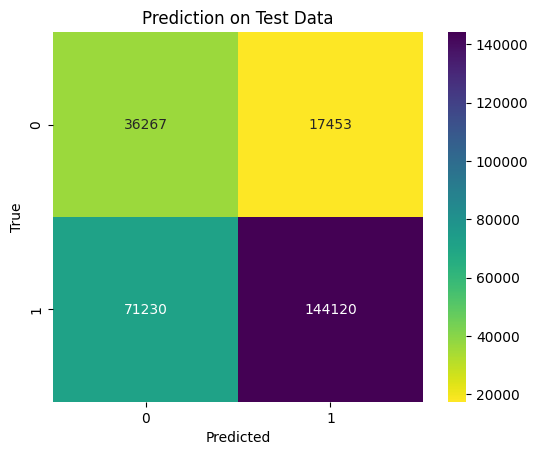

In [359]:
cm = confusion_matrix(y_test.astype('int64'), predictions.astype('int64'))
import seaborn as sns
ax = sns.heatmap(cm, cmap='viridis_r', annot=True, fmt='d', square=True)
ax.set_title('Prediction on Test Data')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

In [ ]:
#accuracy, precision and recall scores of CatBoost predictions on the 2018 data

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
ac1 = accuracy_score(y_test.astype('int64'), predictions.astype('int64'))
#since false positive are more harmful than false negatives, precision_score is the most important metric to track here
pr1 = precision_score(y_test.astype('int64'), predictions.astype('int64'))
re1 = recall_score(y_test.astype('int64'), predictions.astype('int64'))
roc1 = roc_auc_score(y_test.astype('int64'), predictions.astype('int64'))
print('Accuracy Score of %{:.4f}'.format(ac1))
print('Precision Score of %{:.4f}'.format(pr1))
print('Recall Score of %{:.4f}'.format(re1))
print('ROC AUC Score of %{:.4f}'.format(roc1))

Accuracy Score of %0.6704
Precision Score of %0.8920
Recall Score of %0.6692


# Random Forest

## Base Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

rf = RandomForestClassifier(n_jobs=-1, random_state=42)
print("fitting model")
rf.fit(x_train, y_train)
print("model fitted")

Accuracy: 0.8021481398892482
Precision: 0.8035024263120057
Recall: 0.9964847921987462
F1 score:  0.8896484820344014
AUC:  0.5097930290107655


In [389]:
y_rf = rf.predict(x_test)
y_rf_proba = rf.predict_proba(x_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_rf))
print('Precision:', precision_score(y_test, y_rf))
print('Recall:', recall_score(y_test, y_rf))
print('F1 score: ', f1_score(y_test, y_rf))
print('AUC: ', roc_auc_score(y_test, y_rf_proba))

Accuracy: 0.8021481398892482
Precision: 0.8035024263120057
Recall: 0.9964847921987462
F1 score:  0.8896484820344014
AUC:  0.710329708810105


## Hyperparameter Tuning

In [372]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(params):
    rf = RandomForestClassifier(**params)
    score = cross_val_score(rf, x_train, y_train, cv=5, scoring='f1').mean()
    return {'loss': -score, 'status': STATUS_OK}

# Define the search space
space = {
    'n_estimators': hp.choice('n_estimators', [100, 200, 300]),
    'max_depth': hp.choice('max_depth', [5, 10, 15]),
    'min_samples_split': hp.choice('min_samples_split', [2, 5, 10]),
    'min_samples_leaf': hp.choice('min_samples_leaf', [1, 2, 4])
}

# Run the optimization
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Train the model with the best parameters
best_params = {
    'n_estimators': [100, 200, 300][best['n_estimators']],
    'max_depth': [5, 10, 15][best['max_depth']],
    'min_samples_split': [2, 5, 10][best['min_samples_split']],
    'min_samples_leaf': [1, 2, 4][best['min_samples_leaf']]
}

rf_best = RandomForestClassifier(**best_params)
rf_best.fit(x_train, y_train)

100%|██████████| 10/10 [3:25:36<00:00, 1233.67s/trial, best loss: -0.8891052605120088] 


RandomForestClassifier(max_depth=15, min_samples_leaf=2, n_estimators=300)

In [373]:
print(best)

{'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 0, 'n_estimators': 2}


In [374]:
import joblib
joblib.dump(rf_best, "models/rf_hpo.pkl")

['models/rf_hpo.pkl']

In [388]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
# predicting test data
rf_pred = rf_best.predict(x_test)
rf_pred_proba = rf_best.predict_proba(x_test)[:, 1]

ac1 = accuracy_score(y_test.astype('int64'), rf_pred.astype('int64'))
#since false positive are more harmful than false negatives, precision_score is the most important metric to track here
pr1 = precision_score(y_test.astype('int64'), rf_pred.astype('int64'))
re1 = recall_score(y_test.astype('int64'), rf_pred.astype('int64'))
f1 = f1_score(y_test.astype('int64'), rf_pred.astype('int64'))
auc = roc_auc_score(y_test, rf_pred_proba)
print('Accuracy Score of %{:.4f}'.format(ac1))
print('Precision Score of %{:.4f}'.format(pr1))
print('Recall Score of %{:.4f}'.format(re1))
print('F1 Score of %{:.4f}'.format(f1))
print('AUC score of %{:.4f}'.format(auc))

Accuracy Score of %0.8003
Precision Score of %0.8003
Recall Score of %1.0000
F1 Score of %0.8891
AUC score of %0.7132


# XGBoost

## Base Model

In [390]:
# implement xgboost on train data and evaluate on validation data
from xgboost import XGBClassifier

xgb = XGBClassifier(n_jobs=-1)   
xgb.fit(x_train, y_train)

y_xgb = xgb.predict(x_test)
y_xgb_proba = xgb.predict_proba(x_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_xgb))
print('Precision:', precision_score(y_test, y_xgb))
print('Recall:', recall_score(y_test, y_xgb))
print('F1 score: ', f1_score(y_test, y_xgb))
print('AUC: ', roc_auc_score(y_test, y_xgb_proba))

Accuracy: 0.8055821905080462
Precision: 0.8154808897970557
Recall: 0.9784861852797772
F1 score:  0.8895779594972834
AUC:  0.7298726142968701


## Hyperparameter Optimization

In [376]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(params):
    xgb = XGBClassifier(**params, use_label_encoder=False, eval_metric='logloss')
    score = cross_val_score(xgb, x_train, y_train, cv=5, scoring='f1').mean()
    return {'loss': -score, 'status': STATUS_OK}

# Define the search space
space = {
    'n_estimators': hp.choice('n_estimators', [100, 200, 300]),
    'max_depth': hp.choice('max_depth', [3, 5, 7, 10]),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Run the optimization
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Train the model with the best parameters
best_params = {
    'n_estimators': [100, 200, 300][best['n_estimators']],
    'max_depth': [3, 5, 7, 10][best['max_depth']],
    'learning_rate': best['learning_rate'],
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
    'gamma': best['gamma'],
    'reg_alpha': best['reg_alpha'],
    'reg_lambda': best['reg_lambda']
}

xgb_best = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')
xgb_best.fit(x_train, y_train)

# Predicting test data
predictions = xgb_best.predict(x_test)

# save the model
joblib.dump(xgb_best, "models/xgb_hpo.pkl")

# Evaluate the model
ac1 = accuracy_score(y_test.astype('int64'), predictions.astype('int64'))
pr1 = precision_score(y_test.astype('int64'), predictions.astype('int64'))
re1 = recall_score(y_test.astype('int64'), predictions.astype('int64'))
f1 = f1_score(y_test.astype('int64'), predictions.astype('int64'))

print('Accuracy Score of %{:.4f}'.format(ac1))
print('Precision Score of %{:.4f}'.format(pr1))
print('Recall Score of %{:.4f}'.format(re1))
print('F1 Score of %{:.4f}'.format(f1))

  0%|          | 0/10 [00:00<?, ?trial/s, best loss=?]

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [09:57:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [10:01:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [10:04:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [10:07:54] 

 10%|█         | 1/10 [17:04<2:33:38, 1024.24s/trial, best loss: -0.89023402463545]

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [10:14:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [10:16:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [10:19:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [10:21:08] 

 20%|██        | 2/10 [27:51<1:47:01, 802.67s/trial, best loss: -0.89023402463545] 

...

 90%|█████████ | 9/10 [1:30:34<08:42, 522.27s/trial, best loss: -0.8902417822081208]

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [11:28:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [11:30:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [11:32:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [11:34:16] 

100%|██████████| 10/10 [1:40:43<00:00, 604.32s/trial, best loss: -0.8902417822081208]


/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [11:38:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy Score of %0.8064
Precision Score of %0.8139
Recall Score of %0.9828
F1 Score of %0.8904


In [391]:
# Predicting test data
y_xgb = xgb_best.predict(x_test)
y_xgb_proba = xgb_best.predict_proba(x_test)[:, 1]

# Evaluate the model
ac1 = accuracy_score(y_test.astype('int64'), y_xgb.astype('int64'))
pr1 = precision_score(y_test.astype('int64'), y_xgb.astype('int64'))
re1 = recall_score(y_test.astype('int64'), y_xgb.astype('int64'))
f1 = f1_score(y_test.astype('int64'), y_xgb.astype('int64'))
auc = roc_auc_score(y_test, y_xgb_proba)

print('Accuracy Score of %{:.4f}'.format(ac1))
print('Precision Score of %{:.4f}'.format(pr1))
print('Recall Score of %{:.4f}'.format(re1))
print('F1 Score of %{:.4f}'.format(f1))
print('AUC score of %{:.4f}'.format(auc))

Accuracy Score of %0.8064
Precision Score of %0.8139
Recall Score of %0.9828
F1 Score of %0.8904
AUC score of %0.7314


# With Grade Feature

In [508]:
data['earliest_credit_line_years'].dtype

dtype('<m8[ns]')

In [599]:
# split df into train and test, 80% train, 20% test, keep distribution of target feature loan_status the same 

train_data_grade, test_data_grade = train_test_split(data_grade, random_state=42, test_size=0.2, stratify=data_grade['loan_status'])
train_data_grade, validation_data_grade = train_test_split(train_data_grade, random_state=42, test_size=0.25, stratify=train_data_grade['loan_status'])

x_train_grade, y_train_grade = train_data_grade.drop('loan_status', axis=1), train_data_grade['loan_status']
x_val_grade, y_val_grade = validation_data_grade.drop('loan_status', axis=1), validation_data_grade['loan_status']
x_test_grade, y_test_grade = test_data_grade.drop('loan_status', axis=1), test_data_grade['loan_status']

## XGB With Subgrade Feature

In [600]:
# implement xgboost on train data and evaluate on validation data
from xgboost import XGBClassifier

xgb_grade = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='auc', n_jobs=-1)
xgb_grade.fit(x_train_grade, y_train_grade)

/Users/simonlee/Documents/Cypher/P2P-Loan-Risk-Modeling/.venv/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [17:17:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.815518443322969, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, gamma=0.44166703256558976,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.044276128625897415,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, random_state=None, ...)

In [604]:
y_xgb_grade = xgb_grade.predict(x_test_grade)
y_xgb_grade_proba = xgb_grade.predict_proba(x_test_grade)[:, 1]

print('Accuracy:', accuracy_score(y_test_grade.astype('int64'), y_xgb_grade.astype('int64')))
print('Precision:', precision_score(y_test_grade.astype('int64'), y_xgb_grade.astype('int64')))
print('Recall:', recall_score(y_test_grade.astype('int64'), y_xgb_grade.astype('int64')))
print('F1 score: ', f1_score(y_test_grade.astype('int64'), y_xgb_grade.astype('int64')))
print('AUC: ', roc_auc_score(y_test_grade.astype('int64'), y_xgb_grade_proba.astype('float64')))

Accuracy: 0.8065744973426989
Precision: 0.8141652847408456
Recall: 0.9826050615277455
F1 score:  0.8904899074808575
AUC:  0.731798180540743


In [607]:
feature_important = xgb_grade.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

results = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
results.head(20)

,score
loan_amnt,1350.0
dti,1251.0
annual_inc,1217.0
mo_sin_old_rev_tl_op,1199.0
int_rate,1137.0
mo_sin_old_il_acct,892.0
avg_cur_bal,831.0
total_bc_limit,763.0
mths_since_recent_bc,747.0
revol_util,737.0
